### One-time Load Data from Kaggle (must join competition first)

In [ ]:
# import kagglehub

# kagglehub.login()

In [ ]:
# Download latest version
# path = kagglehub.competition_download('rossmann-store-sales')

# print("Path to competition files:", path)

100%|██████████| 6.99M/6.99M [00:02<00:00, 3.37MB/s]

Extracting files...


Path to competition files: /home/aiman-nasir/.cache/kagglehub/competitions/rossmann-store-sales


### EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train_path='/home/aiman-nasir/AI-ML-projects/demand-forecasting/data/train.csv'
test_path='/home/aiman-nasir/AI-ML-projects/demand-forecasting/data/test.csv'

df=pd.read_csv(train_path, parse_dates=['Date'])
df=df.sort_values(['Store', 'Date'])

df_test =pd.read_csv(train_path, parse_dates=['Date'])
df_test=df_test.sort_values(['Store', 'Date'])

df.head()

/tmp/ipykernel_15050/980597422.py:7: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(train_path, parse_dates=['Date'])
/tmp/ipykernel_15050/980597422.py:10: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test =pd.read_csv(train_path, parse_dates=['Date'])


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1016095,1,2,2013-01-01,0,0,0,0,a,1
1014980,1,3,2013-01-02,5530,668,1,0,0,1
1013865,1,4,2013-01-03,4327,578,1,0,0,1
1012750,1,5,2013-01-04,4486,619,1,0,0,1
1011635,1,6,2013-01-05,4997,635,1,0,0,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1017209 entries, 1016095 to 1114
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 77.6+ MB


In [3]:
df.StateHoliday.unique()

array(['a', '0', 'b', 'c', 0], dtype=object)

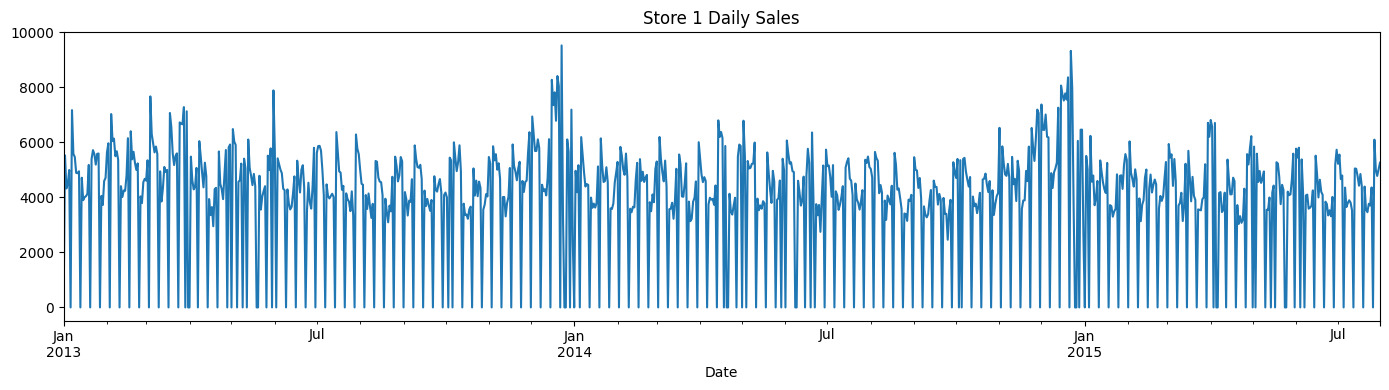

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64


In [4]:
store1 = df[df['Store']==1]
store1.set_index('Date')['Sales'].plot(figsize=(14,4), title='Store 1 Daily Sales')
plt.tight_layout()
plt.show()

print(df.groupby('Promo')['Sales'].mean())

In [5]:
def get_data():
    """
    Return the loaded train and test dataframes for use when this notebook
    is imported as a module via import_ipynb.
    """
    return df, df_test

class RossmannDataLoader:
    @staticmethod
    def load_data():
        """Return copies of the already loaded dataframes."""
        return df.copy(), df_test.copy()

    @staticmethod
    def reload_data():
        """
        Reload the raw CSV files from disk and return fresh dataframes.
        Useful if you want to ensure the original data is read again.
        """
        train = pd.read_csv(train_path, parse_dates=['Date']).sort_values(['Store', 'Date'])
        test = pd.read_csv(test_path, parse_dates=['Date']).sort_values(['Store', 'Date'])
        return train, test